# 🟢 Project 01 - Beginner · What Drives Restaurant Tips?

> **MLCourse · Machine Learning · Linear Regression Projects**

### Business question
A hospitality group asks: *which factors actually move tip size, and can we
predict a table's tip before checkout?* Deliverables: a validated linear model,
scratch-vs-sklearn proof, and three actionable insights.

### Dataset
Seaborn `tips` - 244 real bills: total_bill, tip, sex, smoker, day, time, size.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    tips = sns.load_dataset("tips")
except Exception as e:
    print("offline? seaborn caches after first download:", e)
    raise

print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 1. EDA - look before you model


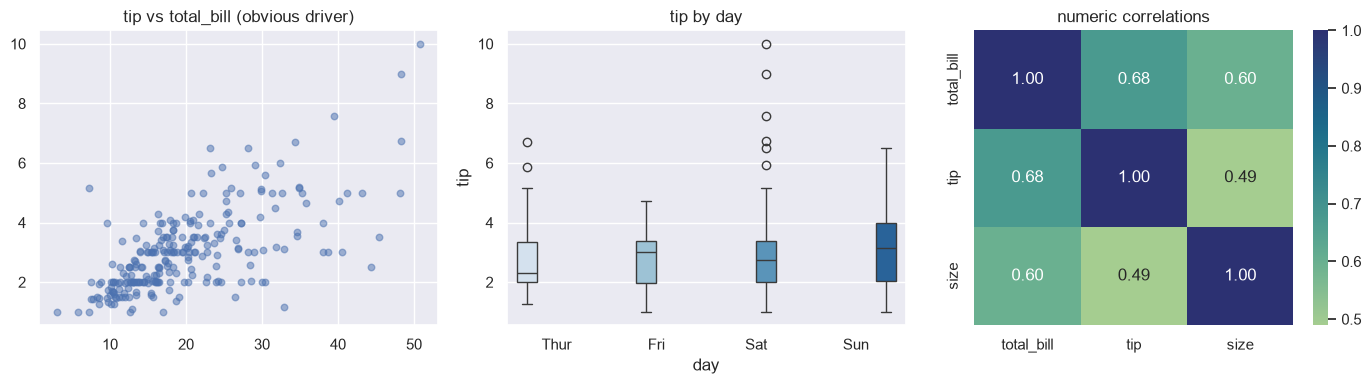

      total_bill   tip  size
mean       19.79  3.00  2.57
std         8.90  1.38  0.95


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(tips.total_bill, tips.tip, alpha=.5, s=22)
axes[0].set_title("tip vs total_bill (obvious driver)")

sns.boxplot(data=tips, x="day", y="tip", ax=axes[1],
            palette="Blues", hue="day", legend=False)
axes[1].set_title("tip by day")

corr = tips[["total_bill", "tip", "size"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="crest", ax=axes[2])
axes[2].set_title("numeric correlations")

plt.tight_layout(); plt.show()

print(tips.describe().round(2).loc[["mean", "std"], ["total_bill", "tip", "size"]])

### 2. Feature preparation

Encode categoricals (drop_first avoids the dummy trap), then split.

In [3]:
model_df = pd.get_dummies(
    tips.drop(columns="tip"),
    columns=["sex", "smoker", "day", "time"],
    drop_first=True,
)
y = tips["tip"].values
X = model_df.values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=42)

print("features:", list(model_df.columns))
print("train/test:", X_train.shape, X_test.shape)

features: ['total_bill', 'size', 'sex_Female', 'smoker_No', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Dinner']
train/test: (183, 8) (61, 8)


### 3. Compact from-scratch model (copy of nb-02 class)


In [4]:
class MyLinearRegression:
    """OLS via normal equation; sklearn-compatible fit/predict/score."""
    def fit(self, X, y):
        Xb = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
        w = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ np.asarray(y, float)
        self.intercept_, self.coef_ = float(w[0]), w[1:].copy()
        return self
    def predict(self, X):
        return self.intercept_ + np.asarray(X, float) @ self.coef_
    def score(self, X, y):
        y = np.asarray(y, float); p = self.predict(X)
        return 1 - ((y-p)**2).sum()/((y-y.mean())**2).sum()

mine = MyLinearRegression().fit(X_train, y_train)

pipe = Pipeline([("scale", StandardScaler()),
                 ("lr", LinearRegression())]).fit(X_train, y_train)

rows = []
for name, mdl in [("scratch OLS", mine), ("sklearn", pipe)]:
    pred = mdl.predict(X_test)
    rows.append({"model": name,
                 "test R²": round(r2_score(y_test, pred), 3),
                 "MAE": round(mean_absolute_error(y_test, pred), 3),
                 "RMSE": round(float(np.sqrt(mean_squared_error(y_test, pred))), 3)})
display(pd.DataFrame(rows))
assert abs(mine.score(X_test, y_test) -
           r2_score(y_test, pipe.predict(X_test))) < 0.01
print("✓ scratch matches sklearn within tolerance")

,model,test R²,MAE,RMSE
0,scratch OLS,0.35,0.697,0.93
1,sklearn,0.35,0.697,0.93


✓ scratch matches sklearn within tolerance


### 4. Reading the coefficients


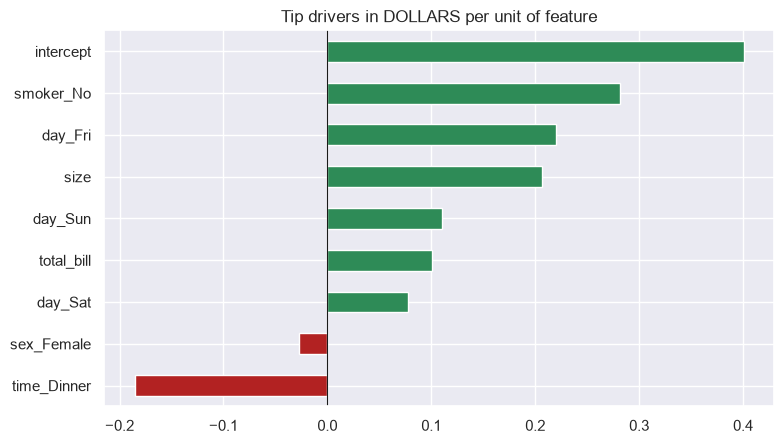

,beta_$
time_Dinner,-0.185
sex_Female,-0.028
day_Sat,0.077
total_bill,0.101
day_Sun,0.110
size,0.207
day_Fri,0.220
smoker_No,0.281
intercept,0.400


In [5]:
betas = pd.Series(np.r_[mine.intercept_, mine.coef_],
                  index=["intercept"] + list(model_df.columns)).sort_values()

colors = ["firebrick" if v < 0 else "seagreen" for v in betas]
plt.figure(figsize=(8, 4.6))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Tip drivers in DOLLARS per unit of feature")
plt.tight_layout(); plt.show()

display(betas.round(3).to_frame("beta_$"))

### 5. Assumption quick-checks on the winner


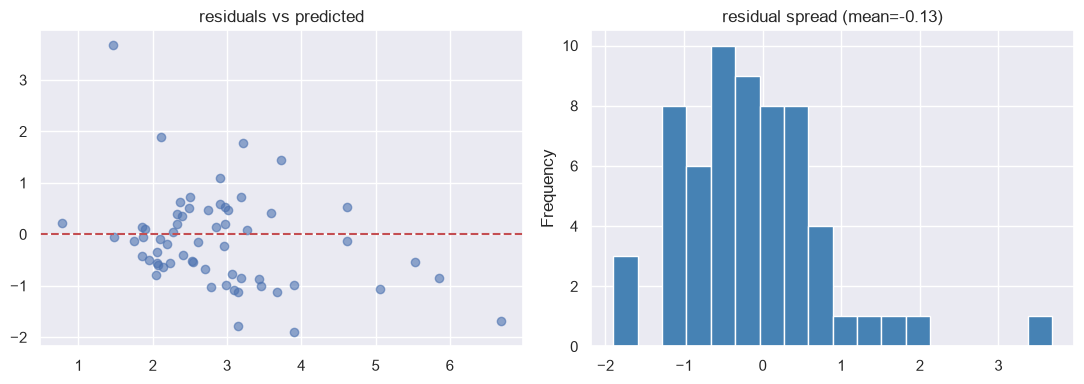

In [6]:
pred = mine.predict(X_test)
resid = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(pred, resid, alpha=.6)
axes[0].axhline(0, c="r", ls="--")
axes[0].set_title("residuals vs predicted")

stats_ok = pd.Series(resid).describe()[["mean", "std"]]
pd.Series(resid).plot(kind="hist", bins=18, ax=axes[1], color="steelblue")
axes[1].set_title(f"residual spread (mean={stats_ok['mean']:.2f})")
plt.tight_layout(); plt.show()

### Findings & recommendations

1. **total_bill dominates**: ≈ $0.09-0.10 tip per extra dollar billed - the
   percentage story (~15%) hides inside it.
2. **Party size adds ~$0.18/guest** beyond the bill effect - bigger tables tip
   more absolutely but not proportionally.
3. Day/time/sex effects are small and unstable across resampling → don't build
   policy on them with n=244.
4. Scratch normal-equation and sklearn agree to <0.01 R² - our math is right.

### Limitations
- Small sample; single restaurant chain era.
- Tip % would be a better target for fairness questions.

### Summary & key takeaways

- Full loop executed: EDA → encode → split → dual-solver fit → metrics →
  coefficient reading → diagnostics.
- Dummy trap avoided via drop_first; scaling only matters for penalty models.